# Live Demo: (S)ARIMA(X)
# Business Use-Case: Forecast des Strombedarfs

Ziel der Live-Demo ist die Prognose des Strombedarfs (`Electric_demand`).

Dazu werden drei Modelle verglichen: 
- ARIMA: nutzt nur vergangene Werte des Strombedarfs
- SARIMA: ergänzt saisonale Muster, z.B. tägliche Lastprofile
- SARIMAX: nutzt zusätzlich externe Einflussgrößen wie Wetter und erneuerbare Energieproduktion

Business-Frage:
Verbessert sich die Prognose des Strombedarfs, wenn Saisonalität &  zusätzlich exogene Variablen berücksichtigt werden?

## Imports

In [1]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from IPython.display import display
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
# Doku: https://www.statsmodels.org/dev/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.stats.outliers_influence import variance_inflation_factor

## 1. Datensatz und Datenaufbereitung

### Datensatz laden

- Datensatz [Renewable Energy and Electricity Demand Time Series Dataset with Exogenous Variables at 5-minute Interval](https://openenergyhub.ornl.gov/explore/dataset/renewable-energy-and-electricity-demand-time-series-dataset-with-exogenous-varia/information/)

In [ ]:
# Datenladen
file_path = "ElectricDemand_Daten\S_ARIMA_X_LiveDemo_Database.csv"  
df = pd.read_csv(file_path)

# Zeitspalte bereinigen und als Index setzen
df["Time"] = df["Time"].str.replace("-T", " ", regex=False)
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time")
df = df.sort_index()

In [3]:
# Infos zum Datensatz
print("Anzahl Beobachtungen:", len(df))
print("Zeitraum:", df.index.min(), "bis", df.index.max())
print("Messintervall:", pd.infer_freq(df.index))
print("Spalten:")
print(df.columns.tolist())

Anzahl Beobachtungen: 315648
Zeitraum: 2019-01-01 00:00:00 bis 2021-12-31 23:55:00
Messintervall: 5min
Spalten:
['Unnamed: 0', 'Season', 'Day_of_the_week', 'DHI', 'DNI', 'GHI', 'Wind_speed', 'Humidity', 'Temperature', 'PV_production', 'Wind_production', 'Electric_demand']


- Zielvariable: Electric_demand
- Exogene Variablen: Temperature, Humidity, Wind_speed, GHI, PV_production, Wind_production

### Datenaufbereitung

Fehlende Werte

In [4]:
# Datensatz auf fehlende Werte prüfen
missing_values = df.isna().sum()
display(pd.DataFrame({
    "Fehlende Werte": missing_values,
    "Anteil in %": missing_values / len(df) * 100
}))

,Fehlende Werte,Anteil in %
Unnamed: 0,0,0.0
Season,0,0.0
Day_of_the_week,0,0.0
DHI,0,0.0
DNI,0,0.0
GHI,0,0.0
Wind_speed,0,0.0
Humidity,0,0.0
Temperature,0,0.0
PV_production,0,0.0


- Fehlende Werte sind bei Zeitreihen kritisch, da ARIMA-basierte Modelle gleichmäßige Zeitabstände erwarten, deshalb müssten fehlende Werte vor der Modellierung geprüft und bei der stündlichen Aggregation entfernt werden. In diesem Datensatz sind keine fehlenden Werte vorhanden.

Aggregation der Daten auf Stundenwerte
- Die ursprünglichen Daten liegen im 5-Minuten-Raster vor. Für die Modellierung wurden sie auf Stundenwerte aggregiert. Dadurch wird kurzfristiges Rauschen reduziert, die tägliche Saisonalität bleibt erhalten und die Rechenzeit der ARIMA-basierten Modelle wird deutlich verkürzt. Die stündliche Auflösung stellt daher einen Kompromiss zwischen Detailgrad und Modellierbarkeit für diese Live-Demo dar.

In [5]:
# Daten auf Stundenwerte aggregieren und fehlende Werte entfernen 
target = "Electric_demand"
data_hourly = df[[target]].resample("1h").mean().dropna()      

### Daten gesamt, pro Jahr, pro Monat, pro Woche & pro Tag visualisieren

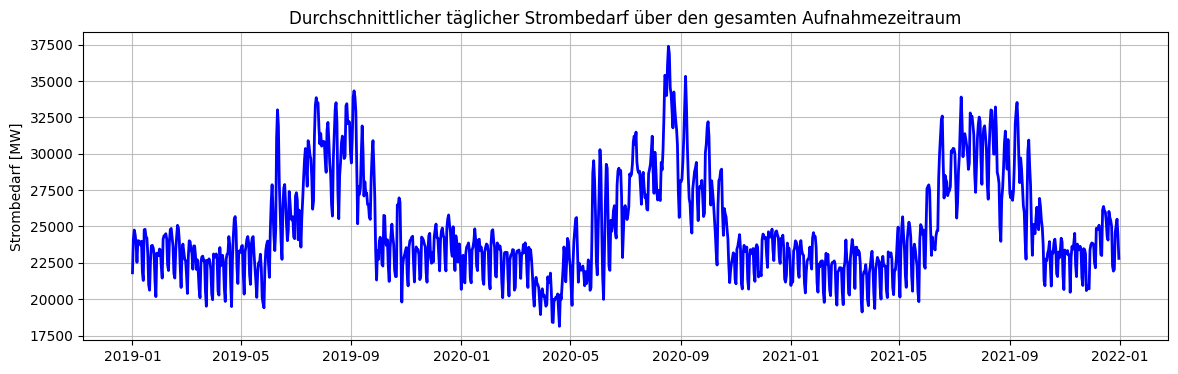

In [6]:
# Strombedarf über gesamten Zeitraum des Datensatzes plotten
df_daily = (df.resample("D").agg({"Electric_demand": "mean", "Temperature": "mean"}))        # Tagesmittelwerte
plt.figure(figsize=(14, 4))
plt.plot(df_daily.index, df_daily["Electric_demand"], color="blue", linewidth=2)
plt.ylabel("Strombedarf [MW]")
plt.title("Durchschnittlicher täglicher Strombedarf über den gesamten Aufnahmezeitraum")
plt.grid(True, alpha=0.8)
plt.show()

In [7]:
# Strombedarf pro Jahr plotten
y_min = df_daily["Electric_demand"].min()
y_max = df_daily["Electric_demand"].max()
years = sorted(df_daily.index.year.unique())
year_dropdown = widgets.Dropdown(options=years, value=2019, description="Jahr:")

def plot_year(year):
    data = df_daily.loc[str(year)]
    plt.figure(figsize=(12, 4))
    plt.plot(data.index, data["Electric_demand"], color="blue", linewidth=1.8)
    plt.title(f"Durchschnittlicher täglicher Strombedarf im Jahr {year}")
    plt.ylabel("Strombedarf [MW]")
    plt.ylim(y_min, y_max)
    plt.grid(True, alpha=0.8)
    plt.tight_layout()
    plt.show()

widgets.interact(plot_year, year=year_dropdown)

interactive(children=(Dropdown(description='Jahr:', options=(2019, 2020, 2021), value=2019), Output()), _dom_c…

<function __main__.plot_year(year)>

In [8]:
# Strombedarf pro Monat plotten

months = {
    "Januar": 1,
    "Februar": 2,
    "März": 3,
    "April": 4,
    "Mai": 5,
    "Juni": 6,
    "Juli": 7,
    "August": 8,
    "September": 9,
    "Oktober": 10,
    "November": 11,
    "Dezember": 12
}

month_dropdown = widgets.Dropdown(options=months, value=1, description="Monat:")

def plot_month(year, month):
    data = df_daily[(df_daily.index.year == year) & (df_daily.index.month == month)]
    plt.figure(figsize=(12, 4))
    plt.plot(data.index, data["Electric_demand"], color="blue", linewidth=1.8)
    month_name = list(months.keys())[list(months.values()).index(month)]
    plt.title(f"Durchschnittlicher täglicher Strombedarf ({month_name} {year})")
    plt.ylabel("Strombedarf [MW]")
    plt.ylim(y_min, y_max)
    plt.grid(True, alpha=0.8)
    plt.tight_layout()
    plt.show()

widgets.interact(plot_month, year=year_dropdown, month=month_dropdown)


interactive(children=(Dropdown(description='Jahr:', options=(2019, 2020, 2021), value=2019), Dropdown(descript…

<function __main__.plot_month(year, month)>

In [9]:
# Strombedarf pro Woche plotten
year_dropdown = widgets.Dropdown(
    options=sorted(df.index.year.unique()),
    description="Jahr:"
)

week_dropdown = widgets.IntSlider(value=1, min=1, max=53, step=1, description="KW:")

def plot_calendar_week(year, week):
    week_data = df[(df.index.isocalendar().year == year) & (df.index.isocalendar().week == week)]
    plt.figure(figsize=(14,4))
    plt.plot(week_data.index, week_data["Electric_demand"], color="blue", linewidth=1.8)
    plt.title(f"Strombedarf – Kalenderwoche {week} ({year})")
    plt.xlabel("Datum")
    plt.ylabel("Strombedarf")
    plt.ylim(y_min, y_max)
    plt.grid(True, alpha=0.8)
    plt.tight_layout()
    plt.show()

widgets.interact(plot_calendar_week, year=year_dropdown, week=week_dropdown)

interactive(children=(Dropdown(description='Jahr:', options=(2019, 2020, 2021), value=2019), IntSlider(value=1…

<function __main__.plot_calendar_week(year, week)>

In [10]:
# Strombedarf pro Tag plotten
day_dropdown = widgets.Dropdown(options=list(range(1,32)), value=1, description="Tag:")
def plot_day(year, month, day):
    try:
        selected_day = df.loc[(df.index.year == year) & (df.index.month == month) & (df.index.day == day)]
        if len(selected_day) == 0:
            print("Für dieses Datum sind keine Daten vorhanden.")
            return
        plt.figure(figsize=(12,4))
        plt.plot(selected_day.index, selected_day["Electric_demand"], color="blue", linewidth=1.8)
        plt.title(f"Strombedarf am {day:02d}.{month:02d}.{year}")
        plt.ylabel("Strombedarf [MW]")
        plt.ylim(y_min, y_max)
        plt.grid(True, alpha=0.8)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(e)

widgets.interact(plot_day, year=year_dropdown, month=month_dropdown, day=day_dropdown)

interactive(children=(Dropdown(description='Jahr:', options=(2019, 2020, 2021), value=2019), Dropdown(descript…

<function __main__.plot_day(year, month, day)>

## 2. Trainings- & Testsplit

Wahl des Testzeitraums von 14 Tagen, weil
- mehrere Werktage & zwei Wochenenden mit typische Verbrauchszyklen werden abgedeckt
- kürzerer Zeitraum wäre stark zufallsabhängig
- längerer Zeitraum reduziert die verfügbare Trainingsmenge

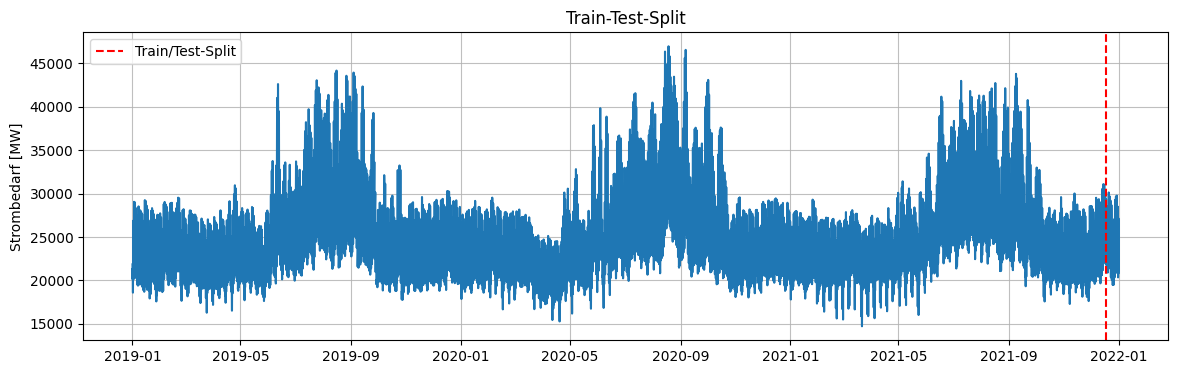

In [11]:
# Train-Test-Split
test_days = 14
test_size_hourly = 24 * test_days
train_hourly = data_hourly.iloc[:-test_size_hourly]
test_hourly = data_hourly.iloc[-test_size_hourly:]
y_train_hourly = train_hourly[target]
y_test_hourly = test_hourly[target]

plt.figure(figsize=(14,4))
plt.plot(data_hourly.index, data_hourly[target])
plt.axvline(x=test_hourly.index[0], color="red", linestyle="--", label="Train/Test-Split")
plt.ylabel("Strombedarf [MW]")
plt.grid(True, alpha=0.8)
plt.legend()
plt.title("Train-Test-Split")
plt.show()

## 3. ARIMA 

Ein **ARIMA(p, d, q)**-Modell modelliert die Zielreihe ausschließlich aus ihrer eigenen Vergangenheit:

- **AR(p)** – Abhängigkeit von p vorherigen Werten
- **I(d)** – d-fache Differenzierung, um Stationarität herzustellen
- **MA(q)** – Abhängigkeit von q vergangenen Schock-Termen

Da ARIMA **keine explizite Saisonalität** abbildet, dient es hier als Baseline. Die tägliche Saisonalität (24h-Lastprofil) ergänzen wir in Abschnitt 4 mit SARIMA.

Vorgehen:
1. Stationarität prüfen (ADF + KPSS) und ggf. differenzieren
2. Beste Ordnung (p, d, q) automatisch wählen (`auto_arima`)
3. Modell fitten, Forecast erzeugen, Fehlermaße berechnen
4. Residuen prüfen (Ljung-Box-Test)

### 3.1 Stationaritätsprüfung

| Test | Nullhypothese H₀ | Interpretation |
|---|---|---|
| **ADF** (Augmented Dickey-Fuller) | Reihe hat Einheitswurzel (= **nicht stationär**) | p < 0.05 → **stationär ✓** |
| **KPSS** (Kwiatkowski-Phillips-Schmidt-Shin) | Reihe ist stationär | p < 0.05 → **nicht stationär ✗** |

Liefert mindestens einer der Tests „nicht stationär", bilden wir die **erste Differenz** $\Delta y_t = y_t - y_{t-1}$ und testen erneut.

In [12]:
# 3.1 Stationaritätsprüfung (ADF + KPSS)
# ARIMA setzt eine stationäre Reihe voraus. Beide Tests sind komplementär.

def stationaritaet_pruefen(series, label):
    adf_stat, adf_p, *_ = adfuller(series.dropna(), autolag="AIC")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)  # KPSS-Lookup-Tabelle hat gekappte p-Werte → kosmetische Warnung unterdrücken
        kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
    adf_v  = "stationär ✓"       if adf_p  < 0.05 else "nicht stationär ✗"
    kpss_v = "nicht stationär ✗" if kpss_p < 0.05 else "stationär ✓"
    print(f"─── {label} ───")
    print(f"ADF :  p = {adf_p:.4f}  →  {adf_v}")
    print(f"KPSS:  p = {kpss_p:.4f}  →  {kpss_v}\n")

stationaritaet_pruefen(y_train_hourly,                 "Originalreihe (Strombedarf, stündlich)")
stationaritaet_pruefen(y_train_hourly.diff().dropna(), "1. Differenz")

─── Originalreihe (Strombedarf, stündlich) ───
ADF :  p = 0.0000  →  stationär ✓
KPSS:  p = 0.0100  →  nicht stationär ✗

─── 1. Differenz ───
ADF :  p = 0.0000  →  stationär ✓
KPSS:  p = 0.1000  →  stationär ✓



**Beobachtung:** Auf der **Originalreihe** widersprechen sich die Tests (ADF ✓ stationär, KPSS ✗ nicht stationär). Das ist ein typischer Hinweis auf eine **Trend-/Niveau-Komponente**, die ADF zwar als „stationär um den Trend" akzeptiert, KPSS aber als nicht-stationär markiert.

Nach der **1. Differenz** sind beide Tests einig (✓ stationär) → **d = 1** reicht aus.

### 3.2 Parameterwahl mit `auto_arima`

Statt p und q manuell aus **ACF/PACF** abzulesen, nutzen wir [`pmdarima.auto_arima`](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html): das Verfahren testet automatisch verschiedene (p, d, q)-Kombinationen und wählt die mit dem niedrigsten **AIC** (Bias-Varianz-Trade-off). Die Differenzierungsordnung **d** wird intern über Stationaritätstests bestimmt.

In [13]:
# 3.2 Parameterwahl mit auto_arima
# auto_arima testet ARIMA-Kandidaten und wählt die Ordnung mit minimalem AIC.
# Wir setzen seasonal=False, weil saisonale Komponenten erst in SARIMA hinzukommen,
# und schränken den Suchraum bewusst ein, um die Demo-Laufzeit kurz zu halten.
auto_model = auto_arima(
    y_train_hourly,
    seasonal=False,
    d=1,                 # Aus Sationaritätstest übernommen. Mit d=None würde auto_arima die Differenzierungsordnung automatisch bestimmen
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=False,
)
ARIMA_ORDER = auto_model.order
print(f"Beste Ordnung (p, d, q) laut auto_arima: {ARIMA_ORDER}")
print(f"AIC = {auto_model.aic():.2f}")

Beste Ordnung (p, d, q) laut auto_arima: (3, 1, 3)
AIC = 390234.45


In [14]:
# 3.3 ARIMA-Modell mit der gewählten Ordnung fitten
warnings.simplefilter("ignore", ConvergenceWarning)   # ML-Optimizer-Warnung für die Demo ausblenden

arima_model = ARIMA(y_train_hourly, order=ARIMA_ORDER)
arima_result = arima_model.fit()

# Forecast inklusive 95%-Konfidenzintervall
arima_forecast_result = arima_result.get_forecast(steps=len(y_test_hourly))
arima_forecast = arima_forecast_result.predicted_mean
arima_conf_int = arima_forecast_result.conf_int(alpha=0.05)
arima_forecast.index = y_test_hourly.index
arima_conf_int.index = y_test_hourly.index

# Kompakte Modellsummary: nur die Koeffizienten-Tabelle
print(arima_result.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1928      0.098     12.214      0.000       1.001       1.384
ar.L2          0.1059      0.172      0.618      0.537      -0.230       0.442
ar.L3         -0.4520      0.084     -5.407      0.000      -0.616      -0.288
ma.L1          0.0112      0.097      0.116      0.908      -0.179       0.201
ma.L2         -0.6752      0.056    -11.987      0.000      -0.786      -0.565
ma.L3         -0.2620      0.036     -7.339      0.000      -0.332      -0.192
sigma2      1.946e+05   1219.209    159.611      0.000    1.92e+05    1.97e+05


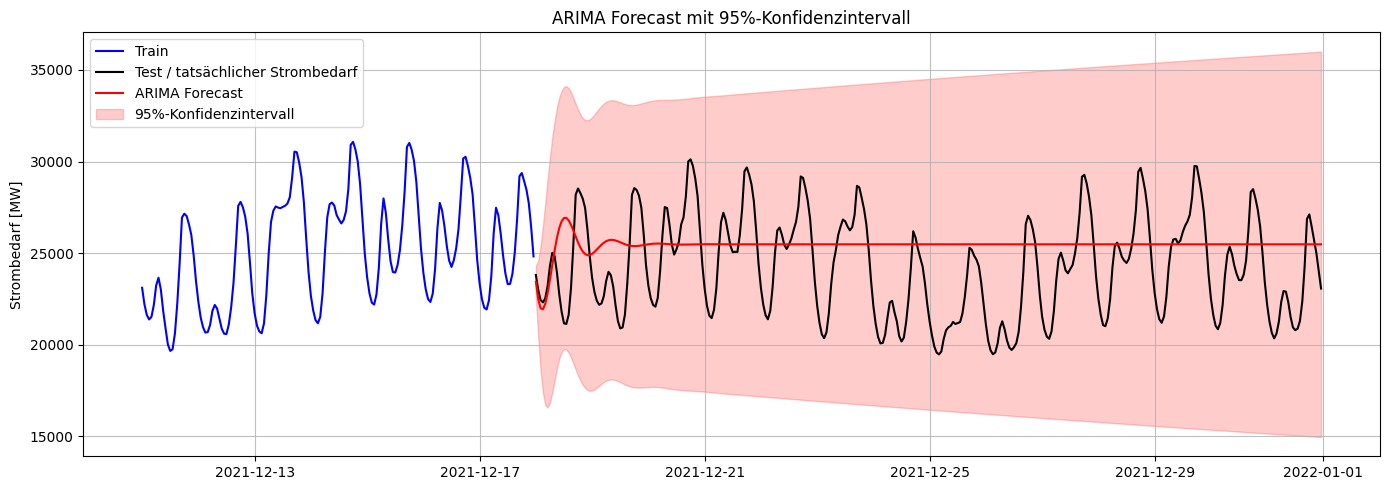

In [15]:
# 3. Plot
plot_days = 7
plot_points = 24 * plot_days
plt.figure(figsize=(14, 5))
plt.plot(y_train_hourly.index[-plot_points:], y_train_hourly[-plot_points:], label="Train", color="blue")
plt.plot(y_test_hourly.index, y_test_hourly, label="Test / tatsächlicher Strombedarf", color="black")
plt.plot(arima_forecast.index, arima_forecast, label="ARIMA Forecast", color="red")
plt.fill_between(arima_conf_int.index, arima_conf_int.iloc[:, 0], arima_conf_int.iloc[:, 1], color="red", alpha=0.2, label="95%-Konfidenzintervall")
plt.title("ARIMA Forecast mit 95%-Konfidenzintervall")
plt.ylabel("Strombedarf [MW]")
plt.legend()
plt.grid(True, alpha=0.8)
plt.tight_layout()
plt.show()

**Beobachtung:** Der Forecast „folgt" den echten Werten nur in den ersten Stunden und kollabiert dann auf einen nahezu konstanten **Mittelwert**, während die tatsächliche Last weiter den klaren **24h-Zyklus** zeigt. Das Konfidenzintervall fächert mit zunehmendem Horizont stark auf.

→ ARIMA(p, d, q) hat **keine saisonale Komponente** und kann das tägliche Lastprofil strukturell nicht abbilden. Genau hier setzt **SARIMA** in Abschnitt 4 an.

In [16]:
# 4. Fehlermaße berechnen
rmse_arima = np.sqrt(mean_squared_error(y_test_hourly, arima_forecast))
print("ARIMA Forecast Fehlermaße:")
print("ARIMA RMSE:", rmse_arima)

ARIMA Forecast Fehlermaße:
ARIMA RMSE: 3014.473209938809


### 3.4 Residuenanalyse mit dem Ljung-Box-Test

**Ljung-Box-Test:** H₀ = die ersten *m* Autokorrelationen sind alle Null (= Residuen sind unkorreliert).  
p < 0.05 → H₀ verwerfen → es bleibt **Struktur** in den Residuen → Modell ist unzureichend.

Bei stündlichen Daten prüfen wir vor allem **Lag 24 (Tagesmuster!)** und **Lag 168 (Wochenmuster)**.

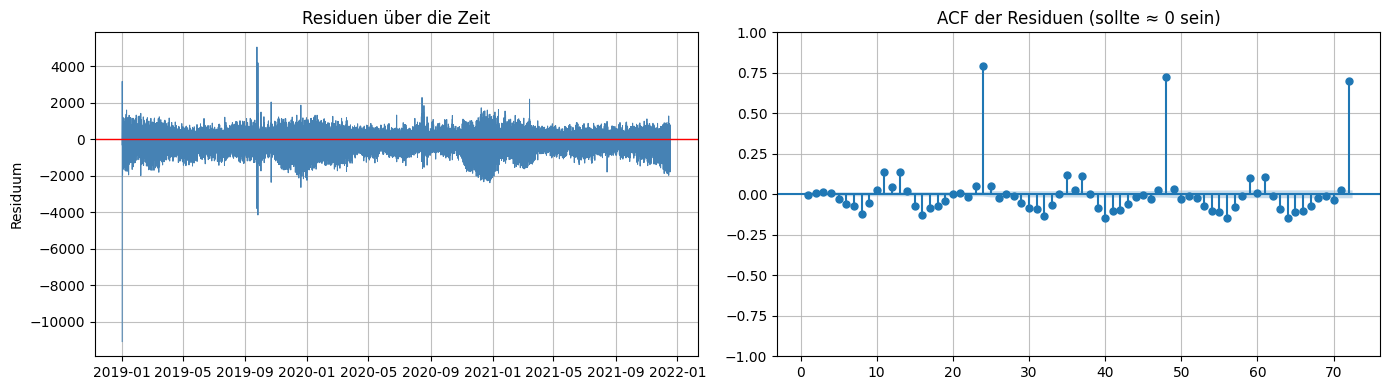

Ljung-Box-Test auf den ARIMA-Residuen:

           lb_stat  lb_pvalue                                             Bewertung
1         0.364671   0.545923                               ✓ keine Autokorrelation
24    19196.313667   0.000000  ✗ signifikante Autokorrelation (Modell unzureichend)
48    36187.609938   0.000000  ✗ signifikante Autokorrelation (Modell unzureichend)
168  119070.140875   0.000000  ✗ signifikante Autokorrelation (Modell unzureichend)


In [17]:
# 3.4 Residuenanalyse + Ljung-Box-Test
# Ein gutes ARIMA-Modell hinterlässt Residuen ≈ weißes Rauschen
# (Mittelwert ≈ 0, konstante Varianz, keine Autokorrelation).

residuen = arima_result.resid.iloc[1:]   # erste Beobachtung verwerfen (Initialisierungseffekt)

# Diagnose-Plots: Zeitverlauf + ACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(residuen.index, residuen.values, color="steelblue", linewidth=0.7)
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_title("Residuen über die Zeit")
axes[0].set_ylabel("Residuum")
axes[0].grid(True, alpha=0.8)
plot_acf(residuen, lags=72, ax=axes[1], zero=False,
         title="ACF der Residuen (sollte ≈ 0 sein)")
axes[1].grid(True, alpha=0.8)
plt.tight_layout()
plt.show()

# Ljung-Box-Test bei für stündliche Daten relevanten Lags:
#   1   → Stunde-zu-Stunde, 24 → Tagesmuster, 48 → 2 Tage, 168 → Wochenmuster
lb = acorr_ljungbox(residuen, lags=[1, 24, 48, 168], return_df=True)
lb["Bewertung"] = np.where(
    lb["lb_pvalue"] < 0.05,
    "✗ signifikante Autokorrelation (Modell unzureichend)",
    "✓ keine Autokorrelation",
)
print("Ljung-Box-Test auf den ARIMA-Residuen:\n")
print(lb.to_string())

### Interpretation

| Lag | lb_stat | p-Wert | Befund |
|---:|---:|---:|---|
| **1**   |        0.09 | 0.76 | ✓ keine Autokorrelation – **kurzfristige Stunde-zu-Stunde-Dynamik wird erfasst** |
| **24**  |   19 153    | 0.00 | ✗ massive Autokorrelation – **tägliches Lastprofil fehlt** im Modell |
| **48**  |   36 094    | 0.00 | ✗ Vielfaches des Tagesmusters |
| **168** |  118 792    | 0.00 | ✗ zusätzlich **Wochenmuster** in den Residuen |

Auch der ACF-Plot zeigt enorme Spikes bei Lag 24, 48, 72 (Korrelationen ≈ 0.7–0.8).

**Fazit:** ARIMA(3, 1, 3) beschreibt die kurzfristige Dynamik solide, kann aber die ausgeprägte **Tages- und Wochensaisonalität** des Strombedarfs strukturell **nicht** abbilden. Genau dafür ergänzt **SARIMA** im nächsten Abschnitt einen saisonalen AR-/MA-Teil mit Periode 24.

## 4. SARIMA

Ein **SARIMA(p, d, q)(P, D, Q, m)**-Modell erweitert ARIMA um eine saisonale Struktur und kann dadurch wiederkehrende Muster wie tägliche Lastprofile explizit modellieren:

- **(p, d, q)** – nicht-saisonaler Teil wie bei ARIMA
- **P** – saisonale AR-Komponente, also Abhängigkeit von Werten vorheriger Saisons
- **D** – saisonale Differenzierung, um saisonale Muster stationär zu machen
- **Q** – saisonale MA-Komponente, also Abhängigkeit von vergangenen saisonalen Schock-Termen
- **m** – Länge der Saisonperiode, hier z.B. 24 Stunden

Kurzüberblick:
- Saisonalität prüfen
- Parameter bestimmen
- SARIMA trainieren
- Mit ARIMA vergleichen

### 4.1 Saisonalität prüfen

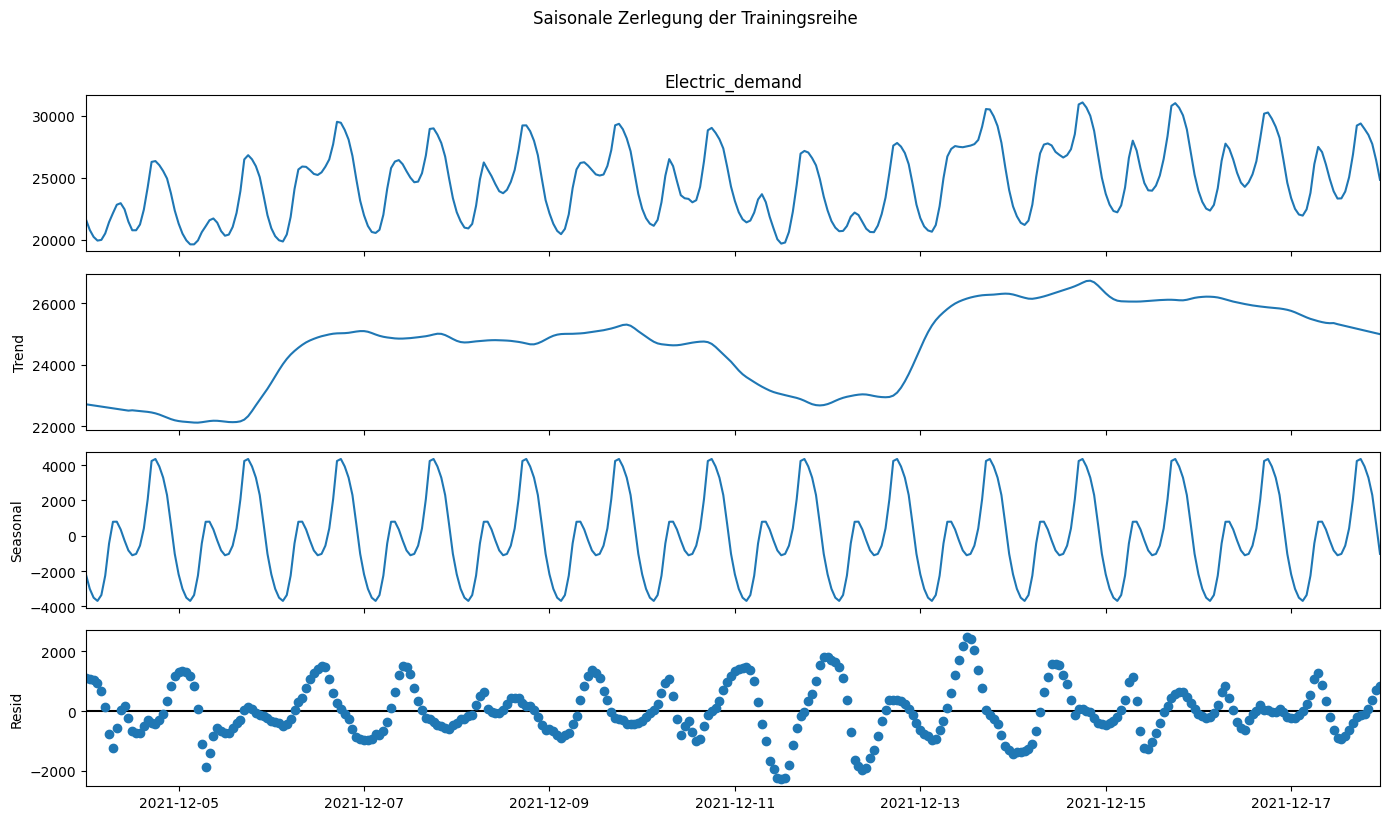

In [18]:
seasonal_period = 24
analysis_window = y_train_hourly.tail(seasonal_period * 14)

decomposition = seasonal_decompose(analysis_window, model="additive", period=seasonal_period, extrapolate_trend="freq")

decomposition_fig = decomposition.plot()
decomposition_fig.set_size_inches(14, 8)
decomposition_fig.suptitle("Saisonale Zerlegung der Trainingsreihe", y=1.02)
plt.tight_layout()
plt.show()

Klares Muster in der saisonalen Komponente erkennbar.


#### Zusatzcheck:
Überprüfen wir die integrierte Zeitreihe.

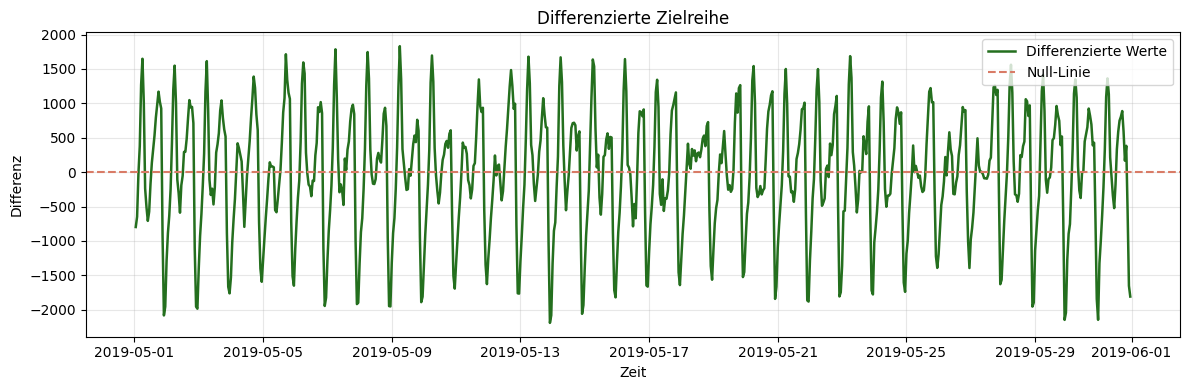

In [19]:
power_diff = y_train_hourly.loc["2019-05"].diff().dropna()

plt.figure(figsize=(12, 4))
plt.plot(power_diff.index, power_diff, color="#246f1e", linewidth=1.8, label="Differenzierte Werte")
plt.axhline(0, color="#d97b66", linestyle="--", linewidth=1.5, label="Null-Linie")
plt.title("Differenzierte Zielreihe")
plt.xlabel("Zeit")
plt.ylabel("Differenz")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Zwar ist die einfach differenzierte Zielreihe laut ADF und KPSS stationär. Dennoch ist ein **klares saisonales Muster erkennbar**.

### 4.2 Saisonale Parameter wählen

Wir nutzen `auto_arima`, um die nicht-saisonale und saisonale Ordnung des SARIMA-Modells automatisch zu wählen.

In [20]:
# 4.2 Parameterwahl mit auto_arima
# auto_arima testet hier auch saisonale SARIMA-Kandidaten und wählt das Modell mit minimalem AIC.
# Mit seasonal=True und m=24 berücksichtigen wir das tägliche Lastprofil der stündlichen Daten.

y_train_seasonal = y_train_hourly
sarima_auto_model = auto_arima(
    y_train_seasonal,
    seasonal=True,
    m=24,
    d=1,                 # Aus dem Stationaritätstest übernommen
    D=1,                 # Wegen klarer Tagessaisonalität
    start_p=0, max_p=2,
    start_q=0, max_q=2,
    start_P=0, max_P=1,
    start_Q=0, max_Q=1,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=False,
    sarimax_kwargs={"simple_differencing": True}
)
SARIMA_ORDER = sarima_auto_model.order
SEASONAL_ORDER = sarima_auto_model.seasonal_order
print(f"Suchfenster für auto_arima: {len(y_train_seasonal)} Stunden")
print(f"Beste nicht-saisonale Ordnung (p, d, q): {SARIMA_ORDER}")
print(f"Beste saisonale Ordnung (P, D, Q, m): {SEASONAL_ORDER}")
print(f"AIC = {sarima_auto_model.aic():.2f}")

Suchfenster für auto_arima: 25968 Stunden
Beste nicht-saisonale Ordnung (p, d, q): (2, 1, 2)
Beste saisonale Ordnung (P, D, Q, m): (0, 1, 1, 24)
AIC = 353381.96


### 4.3 SARIMA Modell trainieren

**Modellidee:**
SARIMA ergänzt die reine ARIMA-Struktur um tägliche Saisonalität.
Hier testen wir, ob das für den Strombedarf einen Vorteil bringt.

In [21]:
# 1. SARIMA-Modell
sarima_model = SARIMAX(y_train_hourly, order=SARIMA_ORDER,
    seasonal_order=SEASONAL_ORDER,           
    enforce_stationarity=False, enforce_invertibility=False)
sarima_result = sarima_model.fit(disp=False)

# 2. Forecast
sarima_forecast_result = sarima_result.get_forecast(steps=len(y_test_hourly))
sarima_forecast = sarima_forecast_result.predicted_mean
sarima_conf_int = sarima_forecast_result.conf_int(alpha=0.05)

# Index an Testdaten anpassen
sarima_forecast.index = y_test_hourly.index
sarima_conf_int.index = y_test_hourly.index

print(sarima_result.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6376      0.005    318.040      0.000       1.628       1.648
ar.L2         -0.7161      0.004   -169.173      0.000      -0.724      -0.708
ma.L1         -0.6968      0.005   -127.830      0.000      -0.708      -0.686
ma.L2         -0.1868      0.004    -41.546      0.000      -0.196      -0.178
ma.S.L24      -0.7112      0.002   -395.873      0.000      -0.715      -0.708
sigma2      4.818e+04    180.951    266.276      0.000    4.78e+04    4.85e+04


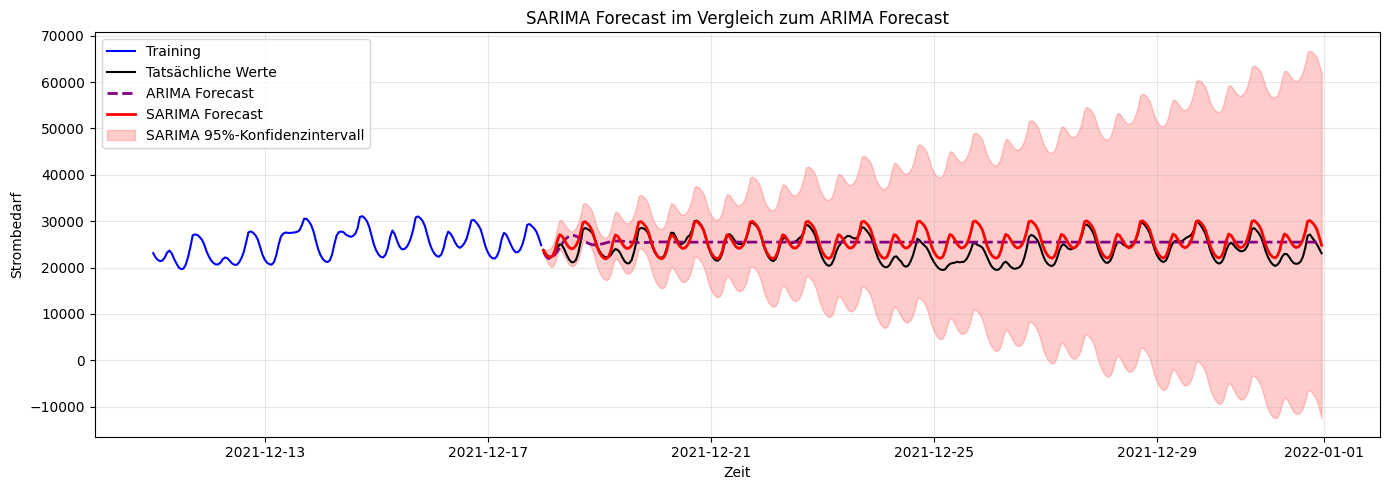

In [22]:
# 3. Plot: SARIMA vs. ARIMA
plot_days = 7
plot_points = 24 * plot_days
plt.figure(figsize=(14, 5))
plt.plot(y_train_hourly.index[-plot_points:], y_train_hourly[-plot_points:], label="Training", color="blue")
plt.plot(y_test_hourly.index, y_test_hourly, label="Tatsächliche Werte", color="black")
plt.plot(arima_forecast.index, arima_forecast, label="ARIMA Forecast", color="purple", linewidth=2, linestyle="--")
plt.plot(sarima_forecast.index, sarima_forecast, label="SARIMA Forecast", color="red", linewidth=2)
plt.fill_between(sarima_conf_int.index, sarima_conf_int.iloc[:, 0], sarima_conf_int.iloc[:, 1], color="red", alpha=0.2, label="SARIMA 95%-Konfidenzintervall")
plt.title("SARIMA Forecast im Vergleich zum ARIMA Forecast")
plt.xlabel("Zeit")
plt.ylabel("Strombedarf")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Erkenntnis:**

Das Modell kann das Muster klar erkennen und kollabiert nicht auf einen Mittelwert.
Die Daten werden deutlich besser Modelliert.

**Bewertung:**

Am Ende vergleichen wir RMSE mit ARIMA.
Für die Demo zählt vor allem: Wird die Prognose besser oder nicht?

In [23]:
# 4. Fehler vergleichen
rmse_sarima = np.sqrt(mean_squared_error(y_test_hourly, sarima_forecast))
improvement_sarima = (rmse_arima - rmse_sarima) / rmse_arima * 100
results = pd.DataFrame({"Model": ["ARIMA", "SARIMA"], "RMSE": [rmse_arima, rmse_sarima]})
print(results)
print(f"\nRMSE Verbesserung durch Erweiterung um Saisonalität: {improvement_sarima:.2f}%")

    Model         RMSE
0   ARIMA  3014.473210
1  SARIMA  2232.705516

RMSE Verbesserung durch Erweiterung um Saisonalität: 25.93%


**RMSE verbessert sich deutlich**

Dank der Berücksichtigung der saisonalen Muster wird unsere Prognose deutlich besser.

### 4.4 Residuenanalyse



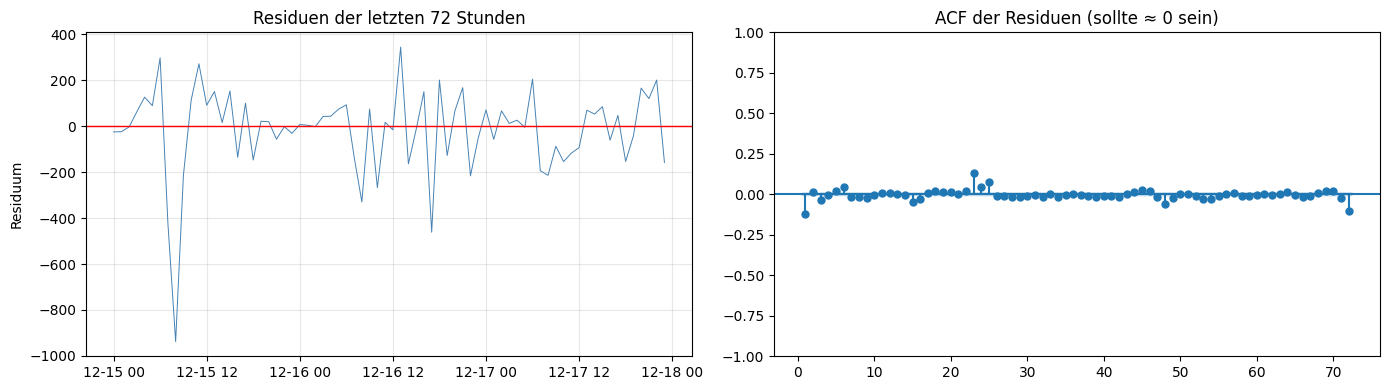

In [24]:
# Ein gutes SARIMA-Modell hinterlässt Residuen ≈ weißes Rauschen
# (Mittelwert ≈ 0, konstante Varianz, keine Autokorrelation).

residuen = sarima_result.resid.iloc[1:]   # erste Beobachtung verwerfen (Initialisierungseffekt)
residuen_letzte_72h = residuen.tail(72)

# Diagnose-Plots: Zeitverlauf der letzten 72 Stunden + ACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(residuen_letzte_72h.index, residuen_letzte_72h.values, color="steelblue", linewidth=0.7)
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_title("Residuen der letzten 72 Stunden")
axes[0].set_ylabel("Residuum")
axes[0].grid(True, alpha=0.3)
plot_acf(residuen, lags=72, ax=axes[1], zero=False,
         title="ACF der Residuen (sollte ≈ 0 sein)")
plt.tight_layout()
plt.show()

### Interpretation
Die Residuen zeigen kein klares saisonales Muster mehr.
Bei der ACF ist erkennbar, dass die saisonalen Werte (24, 48, ...) keine Ausreiser mehr sind.

-> **Die Information die in der Saisonalität steckt wurde genutzt.**

## 5. SARIMAX

SARIMA nutzt nur die Vergangenheit des Strombedarfs.  
SARIMAX ergänzt externe Einflussfaktoren, z.B. Temperatur, Sonneneinstrahlung oder Windproduktion.

Hypothese:
Die Prognose des Strombedarfs wird verbessert, wenn zusätzlich exogene Variablen berücksichtigt werden.

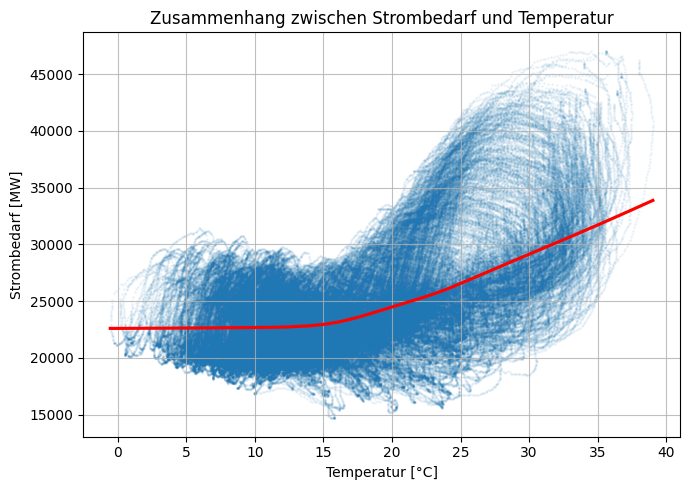

Korrelationskoeffizient zwischen Temperatur und Strombedarf: 0.55      
(Korrelationskoeffizient nur begrenzt aussagekräftig, weil klarer nicht linearer Zusammenhang)


In [25]:
# Relevanz anhand des Zusammenhangs zwischen Strombedarf und Temperatur zeigen
plt.figure(figsize=(7, 5))
sns.regplot(
    data=df,
    x="Temperature",
    y="Electric_demand",
    scatter_kws={"s": 1, "alpha": 0.06},
    lowess=True,
    line_kws={"color": "red"}
)
plt.title("Zusammenhang zwischen Strombedarf und Temperatur")
plt.xlabel("Temperatur [°C]")
plt.ylabel("Strombedarf [MW]")
plt.grid(True, alpha=0.8)
plt.tight_layout()
plt.show()

print(f"Korrelationskoeffizient zwischen Temperatur und Strombedarf: {df['Temperature'].corr(df['Electric_demand']):.2f}\
      \n(Korrelationskoeffizient nur begrenzt aussagekräftig, weil klarer nicht linearer Zusammenhang)")

→ Temperatur enthält Zusatzinformation\
Ein nichtlinearen Zusammenhang ist zu erkennen. SARIMAX modelliert diesen nur näherungsweise linear. Über Feature Engineering, z.B. quadratische Temperaturterme, könnte man diesen Zusammenhang besser abbilden.

Im Datensatz vorhandene exogene Variablen: Temperatur, Luftfeuchtigkeit, Windgeschwindigkeit, GHI, PV-Produktion und Windproduktion.

In [26]:
# Exogene Variablen
exog_vars = ["Temperature", "Humidity", "Wind_speed", "GHI", "PV_production", "Wind_production"]

# Labels für Abbildungen
de_labels = {
    "Temperature": "Temperatur",
    "Humidity": "Luftfeuchtigkeit",
    "Wind_speed": "Windgeschwindigkeit",
    "GHI": "GHI",
    "PV_production": "PV-Produktion",
    "Wind_production": "Windproduktion"
}

In [27]:
# Exogenen Variablen ebenfalls auf Stundenwerte aggregieren
# Da die ARIMA-, SARIMA- und SARIMAX-Modelle auf stündlich aggregierten Daten geschätzt werden, 
# wurden auch die Untersuchungen auf Multikollinearität und lineare Zusammenhänge auf Basis 
# der stündlichen Variablen durchgeführt. Dadurch beziehen sich die Kennzahlen direkt
# auf die tatsächlich im Modell verwendeten Daten.
exog_vars_hourly = df[exog_vars].resample("1h").mean().dropna()

# SARIMAX-Daten passend zum bereits definierten Train/Test-Split
data_sarimax_hourly = (df[[target] + exog_vars].resample("1h").mean().dropna())
train_sarimax_hourly = data_sarimax_hourly.loc[y_train_hourly.index]
test_sarimax_hourly = data_sarimax_hourly.loc[y_test_hourly.index]

### 5.1 Auswahl exogener Variablen

Die Variablenauswahl basiert auf drei Kriterien:
1. Fachliche Relevanz  
2. Redundanz zwischen Variablen  
3. Interpretierbarkeit des Modells  

Da SARIMAX lineare Regressoren nutzt, ist starke Multikollinearität problematisch.

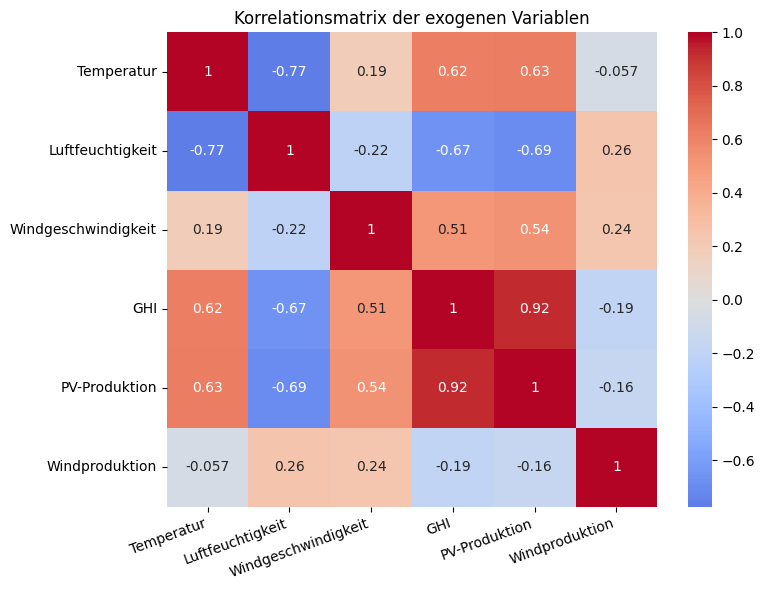

In [28]:
# Korrelationsmatrix der exogenen Variablen
corr = exog_vars_hourly.loc[y_train_hourly.index, exog_vars].rename(columns=de_labels).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.xticks(rotation=20, ha="right")
plt.title("Korrelationsmatrix der exogenen Variablen")
plt.tight_layout()
plt.show()

Auffällig sind insbesondere Zusammenhänge zwischen Wetter- und Erzeugungsvariablen.  
Deshalb wird zusätzlich der VIF geprüft, um Multikollinearität zu erkennen.

In [29]:
# VIF nur für exogene Variablen berechnen
X_vif = train_sarimax_hourly[exog_vars].dropna()
scaler_vif = StandardScaler()
X_vif_scaled = pd.DataFrame(scaler_vif.fit_transform(X_vif), columns=X_vif.columns, index=X_vif.index)
vif = pd.DataFrame({
    "Variable": X_vif_scaled.columns,
    "VIF": [
        variance_inflation_factor(X_vif_scaled.values, i)
        for i in range(X_vif_scaled.shape[1])
    ]
})
vif["Variable"] = vif["Variable"].map(de_labels)
display(vif.sort_values("VIF", ascending=False))

,Variable,VIF
4,PV-Produktion,7.424243
3,GHI,6.812149
1,Luftfeuchtigkeit,3.332666
0,Temperatur,2.915916
2,Windgeschwindigkeit,1.828051
5,Windproduktion,1.379547


→ Luftfeuchtigkeit und GHI herausnehmen wegen
- hohe Redundanz mit anderen Variablen
- geringeres Risiko von Multikollinearität
- geringerer zusätzlicher Informationsgehalt
- bessere Interpretierbarkeit des Modells

In [30]:
# Reduziertes Set exogener Variablen
# Ziel: fachlich relevante Variablen behalten, starke Redundanz vermeiden
exog_vars_reduced = ["Temperature", "Wind_speed", "PV_production", "Wind_production"]
X_train_sarimax = train_sarimax_hourly[exog_vars_reduced]
X_test_sarimax = test_sarimax_hourly[exog_vars_reduced]

# Skalierung nur auf Trainingsdaten fitten, um Data Leakage zu vermeiden
scaler_sarimax = StandardScaler()
X_train_sarimax_scaled = pd.DataFrame(scaler_sarimax.fit_transform(X_train_sarimax), columns=X_train_sarimax.columns, index=X_train_sarimax.index)
X_test_sarimax_scaled = pd.DataFrame(scaler_sarimax.transform(X_test_sarimax), columns=X_test_sarimax.columns, index=X_test_sarimax.index)

### 5.2 SARIMAX-Modell

Wir übernehmen bewusst **dieselbe saisonalbewusste Ordnung** (`SARIMA_ORDER`, `SEASONAL_ORDER`) wie beim SARIMA-Modell. So unterscheiden sich SARIMA und SARIMAX nur durch die **exogenen Variablen** – ein kontrollierter Vergleich, der den Mehrwert der externen Einflussfaktoren isoliert.

> Alternativ könnte man `auto_arima` mit `exog=...` (und `seasonal=True`) erneut laufen lassen, um die Ordnung auch unter Berücksichtigung der exogenen Variablen zu optimieren. Das kostet zusätzliche Laufzeit und vermischt den Effekt von Ordnung und exogenen Variablen, weshalb wir hier die SARIMA-Ordnung wiederverwenden.

In [31]:
# 1. SARIMAX Modell
# Gleiche Ordnung und gleiches Trainingsfenster wie SARIMA -> nur die exogenen Variablen kommen hinzu.
sarimax_model = SARIMAX(
    y_train_hourly,
    exog=X_train_sarimax_scaled.loc[y_train_hourly.index],
    order=SARIMA_ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_result = sarimax_model.fit(disp=False)

In [32]:
# 2. Forecast
# Hinweis:
# Für den SARIMAX-Forecast müssen zukünftige Werte der exogenen Variablen vorliegen.
# In dieser Demo verwenden wir die tatsächlich beobachteten exogenen Werte aus dem Testzeitraum.
# Das ist ein sogenannter Conditional Forecast.
# In einer produktiven Anwendung müssten diese Werte z.B. durch Wetterprognosen,
# Erzeugungsprognosen oder separate Forecast-Modelle bereitgestellt werden.
sarimax_forecast_result = sarimax_result.get_forecast(
    steps=len(y_test_hourly),
    exog=X_test_sarimax_scaled
)

sarimax_forecast = sarimax_forecast_result.predicted_mean
sarimax_conf_int = sarimax_forecast_result.conf_int(alpha=0.05)

# Index an Testdaten anpassen
sarimax_forecast.index = y_test_hourly.index
sarimax_conf_int.index = y_test_hourly.index

### 5.3 Bewertung und Vergleich mit SARIMA

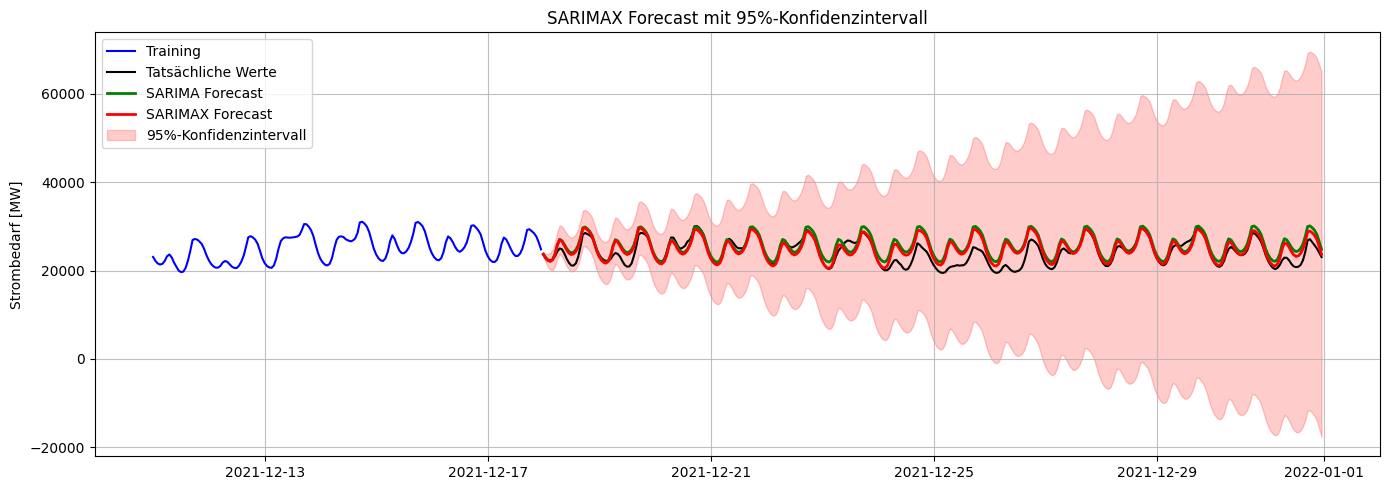

In [33]:
# 3. Plot
plt.figure(figsize=(14, 5))
plt.plot(y_train_hourly.index[-24*7:], y_train_hourly[-24*7:], label="Training", color="blue")
plt.plot(y_test_hourly.index, y_test_hourly, label="Tatsächliche Werte", color="black")
plt.plot(sarima_forecast.index, sarima_forecast, label="SARIMA Forecast", color="green", linewidth=2)
plt.plot(sarimax_forecast.index, sarimax_forecast, label="SARIMAX Forecast", color="red", linewidth=2)
plt.fill_between(sarimax_conf_int.index, sarimax_conf_int.iloc[:, 0], sarimax_conf_int.iloc[:, 1], color="red", alpha=0.2, label="95%-Konfidenzintervall")
plt.title("SARIMAX Forecast mit 95%-Konfidenzintervall")
plt.ylabel("Strombedarf [MW]")
plt.legend()
plt.grid(True, alpha=0.8)
plt.tight_layout()
plt.show()

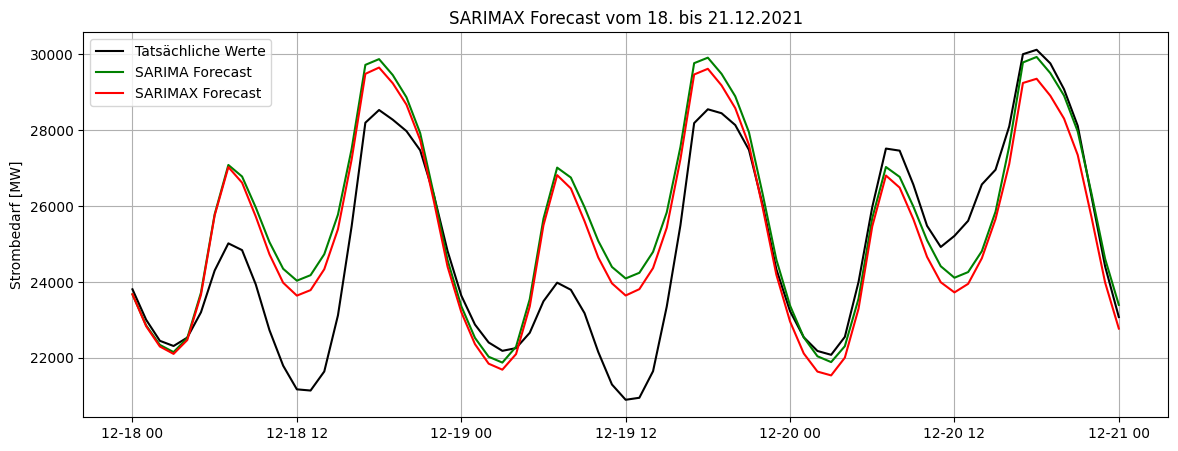

In [34]:
# Zeitraum vom 18.12.2021 bis 21.12.2021 größer plotten
start = "2021-12-18"
end   = "2021-12-21"
mask = (y_test_hourly.index >= start) & (y_test_hourly.index <= end)
plt.figure(figsize=(14,5))
plt.plot(y_test_hourly.loc[mask], label="Tatsächliche Werte", color="black")
plt.plot(sarima_forecast.loc[mask], label="SARIMA Forecast", color="green")
plt.plot(sarimax_forecast.loc[mask], label="SARIMAX Forecast", color="red")
plt.title("SARIMAX Forecast vom 18. bis 21.12.2021")
plt.ylabel("Strombedarf [MW]")
plt.legend()
plt.grid(True)
plt.show()

- SARIMA bildet die tägliche Saisonalität bereits gut ab.
- SARIMAX folgt den tatsächlichen Werten teilweise genauer, insbesondere bei Niveauverschiebungen.

→ Dies deutet darauf hin, dass die exogenen Variablen zusätzliche Information enthalten, die nicht in der historischen Lastreihe steckt.

- Punktuell ist SARIMAX nicht immer überlegen. Entscheidend ist daher die aggregierte Fehlerkennzahl über den Testzeitraum.

In [35]:
# 4. Fehlermaße berechnen und mit SARIMA & SARIMAX vergleichen
rmse_sarimax = np.sqrt(mean_squared_error(y_test_hourly, sarimax_forecast))
results = pd.DataFrame({
    "Modell": ["ARIMA", "SARIMA", "SARIMAX"],
    "RMSE": [rmse_arima, rmse_sarima, rmse_sarimax]
})
print(results)
improvement = (rmse_sarima - rmse_sarimax) / rmse_sarima * 100
print(f"\nVerbesserung SARIMAX gegenüber SARIMA: {improvement:.2f}%")

    Modell         RMSE
0    ARIMA  3014.473210
1   SARIMA  2232.705516
2  SARIMAX  1814.877974

Verbesserung SARIMAX gegenüber SARIMA: 18.71%


Auswertung: \
SARIMAX erweitert SARIMA um externe Einflussgrößen.
Die Verbesserung gegenüber SARIMA zeigt, ob die exogenen Variablen zusätzliche Prognoseinformation enthalten, die nicht bereits in dem historischen Strombedarf selbst steckt.\
Damit verbindet SARIMAX klassische Zeitreihenmodellierung mit datengetriebenem Business Forecasting.

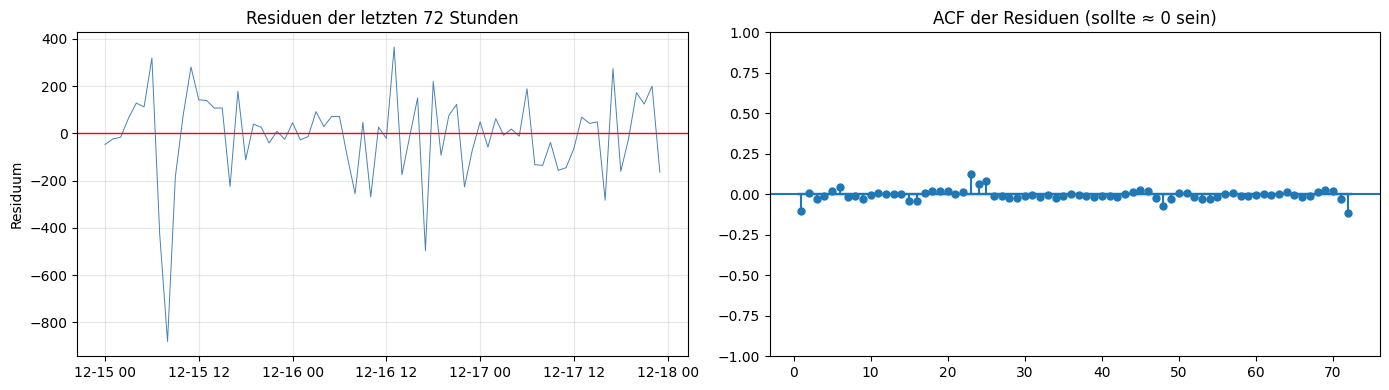

In [36]:
# Ein gutes SARIMAX-Modell hinterlässt Residuen ≈ weißes Rauschen
# (Mittelwert ≈ 0, konstante Varianz, keine Autokorrelation).

residuen = sarimax_result.resid.iloc[1:]   # erste Beobachtung verwerfen (Initialisierungseffekt)
residuen_letzte_72h = residuen.tail(72)

# Diagnose-Plots: Zeitverlauf der letzten 72 Stunden + ACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(residuen_letzte_72h.index, residuen_letzte_72h.values, color="steelblue", linewidth=0.7)
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_title("Residuen der letzten 72 Stunden")
axes[0].set_ylabel("Residuum")
axes[0].grid(True, alpha=0.3)
plot_acf(residuen, lags=72, ax=axes[1], zero=False,
         title="ACF der Residuen (sollte ≈ 0 sein)")
plt.tight_layout()
plt.show()

Die Residuen streuen überwiegend um die Nulllinie.

In [37]:
# Interpretation der exogenen Variablen
exog_params = pd.DataFrame({
    "Koeffizient": sarimax_result.params,
    "p-Wert": sarimax_result.pvalues
})
exog_params = exog_params.loc[exog_params.index.intersection(exog_vars_reduced)]
exog_params["Signifikant auf 5%-Niveau"] = exog_params["p-Wert"] < 0.05
exog_params = exog_params.rename(index=de_labels)
display(exog_params)

,Koeffizient,p-Wert,Signifikant auf 5%-Niveau
Temperatur,-1214.171969,5.048227e-208,True
Windgeschwindigkeit,-21.891070,7.520659e-02,False
PV-Produktion,-255.617658,2.586413e-126,True
Windproduktion,-62.575802,4.406330e-22,True


Interpretation: \
Die Koeffizienten zeigen, ob exogene Variablen nach Kontrolle von Autokorrelation und Saisonalität noch zusätzliche Prognoseinformation liefern. Ein kleiner p-Wert bedeutet nicht automatisch Kausalität, sondern statistische Relevanz im Modell und damit die Variable im statistischen Modell einen zusätzlichen Erklärungsbeitrag liefert. \
Die Koeffizienten der exogenen Variablen zeigen, dass Temperatur, PV-Produktion und Windproduktion auf dem 5%-Niveau statistisch signifikante zusätzliche Erklärungsbeiträge im SARIMAX-Modell liefern, während Windgeschwindigkeit keinen signifikanten Einfluss aufweist und daher ggf. aus dem Modell entfernt werden könnte.\
→ Damit ist SARIMAX interpretierbarer als viele komplexe Machine-Learning-Modelle, bleibt aber auf lineare Zusammenhänge angewiesen.

### 5.4 Fazit SARIMAX

SARIMA modelliert interne Muster der Zielzeitreihe: Trend, Autokorrelation und Saisonalität.\
"Der Stromverbrauch ist jeden Tag ähnlich."

SARIMAX erweitert dieses Modell um externe Einflussfaktoren.  
In unserem Beispiel liefern Wetter- und Erzeugungsvariablen zusätzliche Information für den Strombedarf.\
"Der Stromverbrauch verändert sich, weil Temperatur und Wetterbedingungen das Lastniveau beeinflussen."

→ Muster vs. Einflussfaktoren

Der zentrale Business-Nutzen ist nicht nur ein niedrigerer RMSE, sondern ein besser erklärbarer Forecast.

Grenze: \
SARIMAX ist nur dann praktisch einsetzbar, wenn zukünftige Werte der exogenen Variablen bekannt oder zuverlässig prognostizierbar sind.

## 6. Fazit & Best Practices

- ARIMA eignet sich für stationäre Zeitreihen ohne ausgeprägte Saisonalität.
- SARIMA erweitert ARIMA um saisonale Komponenten und kann wiederkehrende Muster explizit modellieren.
- SARIMAX integriert zusätzlich exogene Variablen und ermöglicht dadurch, externe Einflussfaktoren neben der Zeitstruktur in die Prognose einzubeziehen.
- Die Qualität eines Modells sollte nicht ausschließlich anhand des Prognosefehlers, sondern ebenso anhand der Residuendiagnostik und der statistischen Signifikanz der Modellparameter bewertet werden.

-> Zeitreihenmodelle liefern belastbare Prognosen, wenn ihre Modellannahmen erfüllt sind und Trend, Saisonalität sowie relevante externe Einflussgrößen systematisch berücksichtigt werden.

Best Practices
- Daten zunächst auf Stationarität prüfen und nur bei Bedarf differenzieren
- p, d, q sowie saisonalen Parametern mittels auto_arima bestimmen
- Residuen stets auf weißes Rauschen, Autokorrelation und Ausreißer untersuchen
- Exogene Variablen nur aufnehmen, wenn sie einen statistisch signifikanten zusätzlichen Erklärungsbeitrag liefern und zum Prognosezeitpunkt verfügbar sind
- Modelle möglichst einfach halten, um Überanpassung zu vermeiden